# ✈️ Travel Cost Estimation — Phase I Preprocessing & EDA
**CS313x Spring 2026 | Team: Trippers**

This notebook covers:
- Data Loading & Quality Inspection
- Data Cleaning Pipeline (missing, noisy, duplicates)
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization & Insights

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 📥 1. Load Raw Dataset

In [18]:
df_raw = pd.read_excel('flights_dataset.xlsx')

print('=' * 65)
print('           TRAVEL COST ESTIMATION — RAW DATASET')
print('=' * 65)
print(f'  Total records  : {len(df_raw)}')
print(f'  Total columns  : {len(df_raw.columns)}')
print(f'  Columns        : {list(df_raw.columns)}')
print()
print('📋 DATA TYPES:')
print(df_raw.dtypes.to_string())
print()
df_raw.head()

           TRAVEL COST ESTIMATION — RAW DATASET
  Total records  : 40
  Total columns  : 58
  Columns        : ['origin', 'destination', 'date', 'airline', 'from_time', 'to_time', 'duration', 'stops', 'cabin_class', 'base_price', 'fare_1_cabin', 'fare_1_carry_on', 'fare_1_checked_bag', 'fare_1_price', 'fare_1_seat_selection', 'fare_2_cabin', 'fare_2_carry_on', 'fare_2_checked_bag', 'fare_2_price', 'fare_2_seat_selection', 'fare_3_cabin', 'fare_3_carry_on', 'fare_3_checked_bag', 'fare_3_price', 'fare_3_seat_selection', 'fare_4_cabin', 'fare_4_carry_on', 'fare_4_checked_bag', 'fare_4_price', 'fare_4_seat_selection', 'provider_1_name', 'provider_1_price', 'provider_2_name', 'provider_2_price', 'provider_3_name', 'provider_3_price', 'provider_4_name', 'provider_4_price', 'provider_5_name', 'provider_5_price', 'provider_6_name', 'provider_6_price', 'provider_7_name', 'provider_7_price', 'provider_8_name', 'provider_8_price', 'provider_9_name', 'provider_9_price', 'provider_10_name', 'provid

,origin,destination,date,airline,from_time,to_time,duration,stops,cabin_class,base_price,...,provider_10_name,provider_10_price,provider_11_name,provider_11_price,provider_12_name,provider_12_price,provider_13_name,provider_13_price,provider_14_name,provider_14_price
0,CAI,ICN,2026-05-20,Emirates,8:05 pm,5:00 pm\n+1,14h 55m,1 stop,Eco Saver,594,...,Gotogate,613.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CAI,ICN,2026-05-20,"Air China, Spring Airlines",2:15 pm,3:55 pm\n+1,19h 40m,2 stops,Economy Cabin,580,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CAI,ICN,2026-05-20,Emirates,5:35 pm,5:00 pm\n+1,17h 25m,1 stop,Eco Saver,594,...,Gotogate,613.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CAI,ICN,2026-05-20,Etihad Airways,3:00 pm,10:50 am\n+1,13h 50m,1 stop,Economy Basic,922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CAI,ICN,2026-05-20,Qatar Airways,7:50 pm,5:30 pm\n+1,15h 40m,1 stop,Economy Convenience,853,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 🔍 2. Data Quality Inspection

In [19]:
print('=' * 65)
print('              DATA QUALITY INSPECTION')
print('=' * 65)

# --- 2a. Duplicates ---
duplicates = df_raw.duplicated().sum()
print(f'\n🔁 DUPLICATE ROWS: {duplicates}')

# --- 2b. Missing values ---
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0]
print(f'\n❓ MISSING VALUES (columns with gaps):')
print(missing_report.to_string() if not missing_report.empty else '   None found')

# --- 2c. Invalid prices ---
invalid_prices = (df_raw['base_price'] <= 0).sum()
print(f'\n💸 INVALID PRICES (base_price ≤ 0): {invalid_prices}')

# --- 2d. Outliers via IQR ---
Q1  = df_raw['base_price'].quantile(0.25)
Q3  = df_raw['base_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ((df_raw['base_price'] < lower_bound) | (df_raw['base_price'] > upper_bound)).sum()
print(f'\n📊 IQR OUTLIER DETECTION (base_price):')
print(f'   Q1 = ${Q1:.2f}  |  Q3 = ${Q3:.2f}  |  IQR = ${IQR:.2f}')
print(f'   Normal range : ${lower_bound:.2f} – ${upper_bound:.2f}')
print(f'   Outliers found: {outliers}')

# --- 2e. Noisy/inconsistent text ---
print(f'\n🔤 UNIQUE VALUES — categorical columns:')
for col in ['airline', 'stops', 'cabin_class', 'origin', 'destination']:
    print(f'   {col}: {df_raw[col].unique().tolist()}')

              DATA QUALITY INSPECTION

🔁 DUPLICATE ROWS: 0

❓ MISSING VALUES (columns with gaps):
                       Missing Count  Missing %
fare_1_checked_bag                 2        5.0
fare_1_seat_selection             20       50.0
fare_2_cabin                      13       32.5
fare_2_carry_on                   13       32.5
fare_2_checked_bag                15       37.5
fare_2_price                      13       32.5
fare_2_seat_selection             23       57.5
fare_3_cabin                      22       55.0
fare_3_carry_on                   22       55.0
fare_3_checked_bag                24       60.0
fare_3_price                      22       55.0
fare_3_seat_selection             25       62.5
fare_4_cabin                      38       95.0
fare_4_carry_on                   38       95.0
fare_4_checked_bag                38       95.0
fare_4_price                      38       95.0
fare_4_seat_selection             39       97.5
provider_2_name                    9  

---
## 🔧 3. Data Cleaning Pipeline

In [20]:
print('=' * 65)
print('              DATA CLEANING PIPELINE')
print('=' * 65)

df_clean = df_raw.copy()
initial_count = len(df_clean)

# ─── Step 3.1 — Remove Duplicates ────────────────────────────────
print('\n🔧 STEP 3.1 — Remove Duplicates')
print('-' * 50)
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed = before - len(df_clean)
print(f'   Removed  : {removed} duplicate rows')
print(f'   Remaining: {len(df_clean)} records')

# ─── Step 3.2 — Handle Missing Values ────────────────────────────
print('\n🔧 STEP 3.2 — Handle Missing Values')
print('-' * 50)

# Critical columns — drop rows where these are null
critical_cols = ['origin', 'destination', 'date', 'airline', 'base_price']
before = len(df_clean)
df_clean = df_clean.dropna(subset=critical_cols)
print(f'   Rows dropped (missing critical fields): {before - len(df_clean)}')

# fare_2 columns — fill with fare_1 values (same cabin tier logic)
fare_2_cols = ['fare_2_cabin', 'fare_2_carry_on', 'fare_2_checked_bag',
               'fare_2_price', 'fare_2_seat_selection']
fare_1_map  = {'fare_2_cabin'         : 'fare_1_cabin',
               'fare_2_carry_on'      : 'fare_1_carry_on',
               'fare_2_checked_bag'   : 'fare_1_checked_bag',
               'fare_2_price'         : 'fare_1_price',
               'fare_2_seat_selection': 'fare_1_seat_selection'}
for col, fill_col in fare_1_map.items():
    filled = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(df_clean[fill_col])
    if filled:
        print(f'   {col}: filled {filled} nulls from {fill_col}')

# Provider name/price pairs — fill name with 'N/A', price with NaN (no imputation for pricing)
for i in range(1, 10):
    name_col  = f'provider_{i}_name'
    price_col = f'provider_{i}_price'
    if name_col in df_clean.columns:
        df_clean[name_col] = df_clean[name_col].fillna('N/A')
    if price_col in df_clean.columns:
        df_clean[price_col] = df_clean[price_col].fillna(np.nan)  # keep NaN; excluded from stats

remaining_null = df_clean.isnull().sum().sum()
print(f'   Remaining nulls (provider prices, intentional): {remaining_null}')
print(f'   Records after missing value handling: {len(df_clean)}')

# ─── Step 3.3 — Remove Invalid Prices ────────────────────────────
print('\n🔧 STEP 3.3 — Remove Invalid Prices')
print('-' * 50)
before = len(df_clean)
df_clean = df_clean[df_clean['base_price'] > 0]
print(f'   Removed  : {before - len(df_clean)} records with base_price ≤ 0')
print(f'   Remaining: {len(df_clean)} records')

# ─── Step 3.4 — Standardise Text / Clean Noisy Data ──────────────
print('\n🔧 STEP 3.4 — Standardise Text & Clean Noisy Data')
print('-' * 50)

# Normalise cabin_class: strip " Cabin" suffix to just class name
df_clean['cabin_class'] = df_clean['cabin_class'].str.replace(' Cabin', '', regex=False).str.strip()

# Normalise stops: convert to numeric count
def parse_stops(val):
    if isinstance(val, str):
        val = val.strip().lower()
        if val == 'nonstop':
            return 0
        try:
            return int(val.split()[0])
        except:
            return np.nan
    return val

df_clean['stops_raw']  = df_clean['stops']          # keep original
df_clean['num_stops']  = df_clean['stops'].apply(parse_stops).astype('Int64')

# Parse duration to minutes
def duration_to_minutes(d):
    if not isinstance(d, str):
        return np.nan
    d = d.strip().lower()
    hours   = 0
    minutes = 0
    if 'h' in d:
        parts = d.split('h')
        try: hours = int(parts[0].strip())
        except: pass
        if len(parts) > 1 and 'm' in parts[1]:
            try: minutes = int(parts[1].replace('m','').strip())
            except: pass
    elif 'm' in d:
        try: minutes = int(d.replace('m','').strip())
        except: pass
    return hours * 60 + minutes

df_clean['duration_min'] = df_clean['duration'].apply(duration_to_minutes)

# Strip leading/trailing whitespace from all string columns
str_cols = df_clean.select_dtypes(include='object').columns
df_clean[str_cols] = df_clean[str_cols].apply(lambda c: c.str.strip() if c.dtype == 'object' else c)

print(f'   cabin_class standardised → unique: {df_clean["cabin_class"].unique().tolist()}')
print(f'   num_stops parsed          → unique: {df_clean["num_stops"].unique().tolist()}')
print(f'   duration_min parsed       → sample: {df_clean["duration_min"].tolist()}')
print(f'   Whitespace stripped from all text columns')

# ─── Step 3.5 — Flag Outliers (retain, do not remove) ────────────
print('\n🔧 STEP 3.5 — Flag Outliers (IQR Method — retain flagged rows)')
print('-' * 50)
Q1  = df_clean['base_price'].quantile(0.25)
Q3  = df_clean['base_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_clean['is_outlier'] = ((df_clean['base_price'] < lower_bound) |
                          (df_clean['base_price'] > upper_bound))
outlier_count = df_clean['is_outlier'].sum()
print(f'   IQR range : ${lower_bound:.2f} – ${upper_bound:.2f}')
print(f'   Flagged   : {outlier_count} outlier(s) (retained with flag)')

print(f'\n✅ CLEANING SUMMARY')
print(f'   Raw records    : {initial_count}')
print(f'   Clean records  : {len(df_clean)}')
print(f'   Removed total  : {initial_count - len(df_clean)}')

              DATA CLEANING PIPELINE

🔧 STEP 3.1 — Remove Duplicates
--------------------------------------------------
   Removed  : 0 duplicate rows
   Remaining: 40 records

🔧 STEP 3.2 — Handle Missing Values
--------------------------------------------------
   Rows dropped (missing critical fields): 0
   fare_2_cabin: filled 13 nulls from fare_1_cabin
   fare_2_carry_on: filled 13 nulls from fare_1_carry_on
   fare_2_checked_bag: filled 15 nulls from fare_1_checked_bag
   fare_2_price: filled 13 nulls from fare_1_price
   fare_2_seat_selection: filled 23 nulls from fare_1_seat_selection
   Remaining nulls (provider prices, intentional): 854
   Records after missing value handling: 40

🔧 STEP 3.3 — Remove Invalid Prices
--------------------------------------------------
   Removed  : 0 records with base_price ≤ 0
   Remaining: 40 records

🔧 STEP 3.4 — Standardise Text & Clean Noisy Data
--------------------------------------------------
   cabin_class standardised → unique: ['Eco S

---
## ✨ 4. Feature Engineering

In [21]:
print('=' * 65)
print('              FEATURE ENGINEERING')
print('=' * 65)

# ── 4.1 Tax & Total Cost ──────────────────────────────────────────
TAX_RATE = 0.15
df_clean['tax']        = (df_clean['base_price'] * TAX_RATE).round(2)
df_clean['total_cost'] = (df_clean['base_price'] + df_clean['tax']).round(2)

# ── 4.2 Budget Level ─────────────────────────────────────────────
def budget_label(x):
    if x < 200:   return 'Low (< $200)'
    elif x < 500: return 'Medium ($200–$500)'
    else:         return 'High (> $500)'

df_clean['budget_level'] = df_clean['total_cost'].apply(budget_label)

# ── 4.3 Affordability Score (higher = cheaper) ────────────────────
df_clean['affordability_score'] = (1000 / df_clean['total_cost']).round(4)

# ── 4.4 Date Features ────────────────────────────────────────────
df_clean['travel_date'] = pd.to_datetime(df_clean['date'])
df_clean['day_of_week'] = df_clean['travel_date'].dt.day_name()
df_clean['month']       = df_clean['travel_date'].dt.month_name()

# ── 4.5 Route label ──────────────────────────────────────────────
df_clean['route'] = df_clean['origin'] + ' → ' + df_clean['destination']

# ── 4.6 Best provider (lowest price across all providers) ─────────
provider_price_cols = [f'provider_{i}_price' for i in range(1, 10)
                       if f'provider_{i}_price' in df_clean.columns]
provider_name_cols  = [f'provider_{i}_name'  for i in range(1, 10)
                       if f'provider_{i}_name'  in df_clean.columns]

df_clean['best_provider_price'] = df_clean[provider_price_cols].min(axis=1)
df_clean['best_provider_name']  = df_clean[provider_name_cols + provider_price_cols].apply(
    lambda row: row[provider_name_cols[row[provider_price_cols].values.argmin()]]
    if row[provider_price_cols].notna().any() else 'N/A', axis=1
)
df_clean['savings_vs_best'] = (df_clean['base_price'] - df_clean['best_provider_price']).round(2)

print('   ✅ tax (15%), total_cost')
print('   ✅ budget_level (Low / Medium / High)')
print('   ✅ affordability_score (1000 / total_cost)')
print('   ✅ day_of_week, month (from date)')
print('   ✅ route (origin → destination)')
print('   ✅ best_provider_name, best_provider_price, savings_vs_best')
print(f'   ✅ num_stops (int), duration_min (minutes)')

# ── 4.7 Final column selection ────────────────────────────────────
final_columns = [
    'origin', 'destination', 'route',
    'date', 'day_of_week', 'month',
    'airline', 'duration', 'duration_min', 'from_time', 'to_time',
    'stops_raw', 'num_stops', 'cabin_class',
    'base_price', 'tax', 'total_cost',
    'fare_1_price', 'fare_2_price',
    'best_provider_name', 'best_provider_price', 'savings_vs_best',
    'budget_level', 'affordability_score', 'is_outlier'
]
df_clean = df_clean[[c for c in final_columns if c in df_clean.columns]]

print(f'\n   Final columns  : {len(df_clean.columns)}')
print(f'   Final records  : {len(df_clean)}')
print()
df_clean.head()

              FEATURE ENGINEERING
   ✅ tax (15%), total_cost
   ✅ budget_level (Low / Medium / High)
   ✅ affordability_score (1000 / total_cost)
   ✅ day_of_week, month (from date)
   ✅ route (origin → destination)
   ✅ best_provider_name, best_provider_price, savings_vs_best
   ✅ num_stops (int), duration_min (minutes)

   Final columns  : 25
   Final records  : 40



,origin,destination,route,date,day_of_week,month,airline,duration,duration_min,from_time,...,tax,total_cost,fare_1_price,fare_2_price,best_provider_name,best_provider_price,savings_vs_best,budget_level,affordability_score,is_outlier
0,CAI,ICN,CAI → ICN,2026-05-20,Wednesday,May,Emirates,14h 55m,895,8:05 pm,...,89.10,683.10,594,644.0,Expedia,594.0,0.0,High (> $500),1.4639,False
1,CAI,ICN,CAI → ICN,2026-05-20,Wednesday,May,"Air China, Spring Airlines",19h 40m,1180,2:15 pm,...,87.00,667.00,580,580.0,Kiwi.com,580.0,0.0,High (> $500),1.4993,False
2,CAI,ICN,CAI → ICN,2026-05-20,Wednesday,May,Emirates,17h 25m,1045,5:35 pm,...,89.10,683.10,594,644.0,Expedia,594.0,0.0,High (> $500),1.4639,False
3,CAI,ICN,CAI → ICN,2026-05-20,Wednesday,May,Etihad Airways,13h 50m,830,3:00 pm,...,138.30,1060.30,922,966.0,Gotogate,922.0,0.0,High (> $500),0.9431,True
4,CAI,ICN,CAI → ICN,2026-05-20,Wednesday,May,Qatar Airways,15h 40m,940,7:50 pm,...,127.95,980.95,853,893.0,Qatar Airways,853.0,0.0,High (> $500),1.0194,True


---
## 📊 5. Exploratory Data Analysis (EDA)

In [22]:
print('=' * 65)
print('     EXPLORATORY DATA ANALYSIS (EDA)')
print('=' * 65)

# ── 5.1 Descriptive Statistics ────────────────────────────────────
print('\n📊 5.1 DESCRIPTIVE STATISTICS — Numeric Columns')
print('-' * 55)
num_cols = ['base_price', 'tax', 'total_cost', 'affordability_score',
            'duration_min', 'num_stops', 'savings_vs_best']
num_cols = [c for c in num_cols if c in df_clean.columns]
print(df_clean[num_cols].describe().round(2).to_string())

     EXPLORATORY DATA ANALYSIS (EDA)

📊 5.1 DESCRIPTIVE STATISTICS — Numeric Columns
-------------------------------------------------------
       base_price     tax  total_cost  affordability_score  duration_min  num_stops  savings_vs_best
count       40.00   40.00       40.00                40.00         40.00       40.0            40.00
mean       456.88   68.53      525.41                 2.18        885.12       0.85             3.45
std        191.65   28.75      220.40                 0.84        554.86       0.58            18.00
min        169.00   25.35      194.35                 0.73        260.00        0.0           -10.00
25%        329.75   49.46      379.21                 1.88        367.50       0.75             0.00
50%        439.00   65.85      504.85                 1.98        917.50        1.0             0.00
75%        463.25   69.49      532.74                 2.64       1232.50        1.0             0.25
max       1194.00  179.10     1373.10              

In [23]:
# ── 5.2 Price Analysis by Destination ────────────────────────────
print('\n📊 5.2 PRICE ANALYSIS BY DESTINATION')
print('-' * 55)
dest_analysis = df_clean.groupby('destination').agg(
    flight_count   = ('base_price', 'count'),
    avg_base_price = ('base_price', 'mean'),
    min_price      = ('base_price', 'min'),
    max_price      = ('base_price', 'max'),
    avg_total_cost = ('total_cost', 'mean'),
    avg_afford     = ('affordability_score', 'mean')
).round(2)
print(dest_analysis.to_string())

cheapest_dest        = df_clean.groupby('destination')['base_price'].mean().idxmin()
cheapest_price       = df_clean.groupby('destination')['base_price'].mean().min()
most_expensive_dest  = df_clean.groupby('destination')['base_price'].mean().idxmax()
most_expensive_price = df_clean.groupby('destination')['base_price'].mean().max()
print(f'\n   🏆 Cheapest destination   : {cheapest_dest} (avg ${cheapest_price:.2f})')
print(f'   💰 Most expensive         : {most_expensive_dest} (avg ${most_expensive_price:.2f})')
print(f'   📈 Price difference       : ${most_expensive_price - cheapest_price:.2f}')


📊 5.2 PRICE ANALYSIS BY DESTINATION
-------------------------------------------------------
             flight_count  avg_base_price  min_price  max_price  avg_total_cost  avg_afford
destination                                                                                
CAI                    20          454.95        188       1194          523.19        2.17
ICN                    10          581.10        416        922          668.26        1.62
PAR                    10          336.50        169        458          386.98        2.78

   🏆 Cheapest destination   : PAR (avg $336.50)
   💰 Most expensive         : ICN (avg $581.10)
   📈 Price difference       : $244.60


In [24]:
# ── 5.3 Route Analysis ────────────────────────────────────────────
print('\n✈️  5.3 ROUTE ANALYSIS')
print('-' * 55)
route_analysis = df_clean.groupby('route').agg(
    count     = ('base_price', 'count'),
    avg_price = ('base_price', 'mean'),
    min_price = ('base_price', 'min'),
    max_price = ('base_price', 'max')
).round(2)
print(route_analysis.to_string())


✈️  5.3 ROUTE ANALYSIS
-------------------------------------------------------
           count  avg_price  min_price  max_price
route                                            
CAI → ICN     10      581.1        416        922
CAI → PAR     10      336.5        169        458
ICN → CAI     10      446.1        370        695
PAR → CAI     10      463.8        188       1194


In [25]:
# ── 5.4 Airline Analysis ─────────────────────────────────────────
print('\n🛫 5.4 AIRLINE ANALYSIS')
print('-' * 55)
airline_analysis = df_clean.groupby('airline').agg(
    count          = ('base_price', 'count'),
    avg_price      = ('base_price', 'mean'),
    avg_total_cost = ('total_cost', 'mean'),
    avg_duration   = ('duration_min', 'mean')
).round(2)
print(airline_analysis.to_string())


🛫 5.4 AIRLINE ANALYSIS
-------------------------------------------------------
                                  count  avg_price  avg_total_cost  avg_duration
airline                                                                         
Air China, Spring Airlines            1     580.00          667.00       1180.00
Air France                            3     703.33          808.83        273.33
Ajet                                  1     303.00          348.45        595.00
Asiana Airlines, Hainan Airlines      1     370.00          425.50       1715.00
Austrian Airlines                     1     329.00          378.35        460.00
China Eastern                        11     427.27          491.36       1351.82
Egyptair                              4     424.25          487.89        270.00
Emirates                              3     594.00          683.10        945.00
Etihad Airways                        1     922.00         1060.30        830.00
ITA Airways                  

In [26]:
# ── 5.5 Budget Distribution ───────────────────────────────────────
print('\n💳 5.5 BUDGET LEVEL DISTRIBUTION')
print('-' * 55)
budget_dist = df_clean['budget_level'].value_counts()
budget_pct  = (budget_dist / len(df_clean) * 100).round(1)
budget_df   = pd.DataFrame({'Count': budget_dist, 'Percentage (%)': budget_pct})
print(budget_df.to_string())


💳 5.5 BUDGET LEVEL DISTRIBUTION
-------------------------------------------------------
                    Count  Percentage (%)
budget_level                             
High (> $500)          21            52.5
Medium ($200–$500)     18            45.0
Low (< $200)            1             2.5


In [27]:
# ── 5.6 Provider Comparison ───────────────────────────────────────
print('\n🏪 5.6 PROVIDER PRICE COMPARISON (best offers)')
print('-' * 55)
provider_summary = df_clean[['route', 'airline', 'base_price',
                              'best_provider_name', 'best_provider_price',
                              'savings_vs_best']].copy()
print(provider_summary.to_string(index=False))


🏪 5.6 PROVIDER PRICE COMPARISON (best offers)
-------------------------------------------------------
    route                          airline  base_price best_provider_name  best_provider_price  savings_vs_best
CAI → ICN                         Emirates         594            Expedia                594.0              0.0
CAI → ICN       Air China, Spring Airlines         580           Kiwi.com                580.0              0.0
CAI → ICN                         Emirates         594            Expedia                594.0              0.0
CAI → ICN                   Etihad Airways         922           Gotogate                922.0              0.0
CAI → ICN                    Qatar Airways         853      Qatar Airways                853.0              0.0
CAI → ICN                    China Eastern         421           Kiwi.com                421.0              0.0
CAI → ICN                    China Eastern         416           Kiwi.com                416.0              0.0
C

In [28]:
# ── 5.7 Top Affordable & Most Expensive ──────────────────────────
print('\n🎯 5.7 TOP AFFORDABLE FLIGHTS (highest affordability score)')
print('-' * 55)
top_affordable_cols = ['route', 'airline', 'base_price', 'total_cost',
                       'affordability_score', 'budget_level']
top_affordable_cols = [c for c in top_affordable_cols if c in df_clean.columns]
print(df_clean.nlargest(min(5, len(df_clean)), 'affordability_score')[top_affordable_cols].to_string(index=False))

print('\n💰 5.8 TOP EXPENSIVE FLIGHTS')
print('-' * 55)
top_expensive_cols = ['route', 'airline', 'base_price', 'total_cost', 'budget_level']
top_expensive_cols = [c for c in top_expensive_cols if c in df_clean.columns]
print(df_clean.nlargest(min(5, len(df_clean)), 'base_price')[top_expensive_cols].to_string(index=False))


🎯 5.7 TOP AFFORDABLE FLIGHTS (highest affordability score)
-------------------------------------------------------
    route            airline  base_price  total_cost  affordability_score       budget_level
CAI → PAR  Nile Air, Ryanair         169      194.35               5.1454       Low (< $200)
PAR → CAI  Multiple airlines         188      216.20               4.6253 Medium ($200–$500)
PAR → CAI easyJet, Air Cairo         259      297.85               3.3574 Medium ($200–$500)
CAI → PAR               Ajet         303      348.45               2.8699 Medium ($200–$500)
CAI → PAR   Transavia France         307      353.05               2.8325 Medium ($200–$500)

💰 5.8 TOP EXPENSIVE FLIGHTS
-------------------------------------------------------
    route          airline  base_price  total_cost  budget_level
PAR → CAI       Air France        1194     1373.10 High (> $500)
CAI → ICN   Etihad Airways         922     1060.30 High (> $500)
CAI → ICN    Qatar Airways         853      98

In [29]:
# ── 5.8 Correlation Matrix ────────────────────────────────────────
print('\n🔗 5.9 CORRELATION MATRIX — Numeric Features')
print('-' * 55)
corr_cols = [c for c in ['base_price', 'tax', 'total_cost',
                          'affordability_score', 'duration_min', 'num_stops']
             if c in df_clean.columns]
corr = df_clean[corr_cols].corr().round(3)
print(corr.to_string())


🔗 5.9 CORRELATION MATRIX — Numeric Features
-------------------------------------------------------
                     base_price    tax  total_cost  affordability_score  duration_min  num_stops
base_price                1.000  1.000       1.000               -0.813        -0.146     -0.191
tax                       1.000  1.000       1.000               -0.813        -0.146     -0.191
total_cost                1.000  1.000       1.000               -0.813        -0.146     -0.191
affordability_score      -0.813 -0.813      -0.813                1.000         0.161      0.320
duration_min             -0.146 -0.146      -0.146                0.161         1.000      0.736
num_stops                -0.191 -0.191      -0.191                0.320         0.736      1.000


---
## 📈 6. Data Visualization

✅  Dashboard saved: flight_analysis_dashboard.png


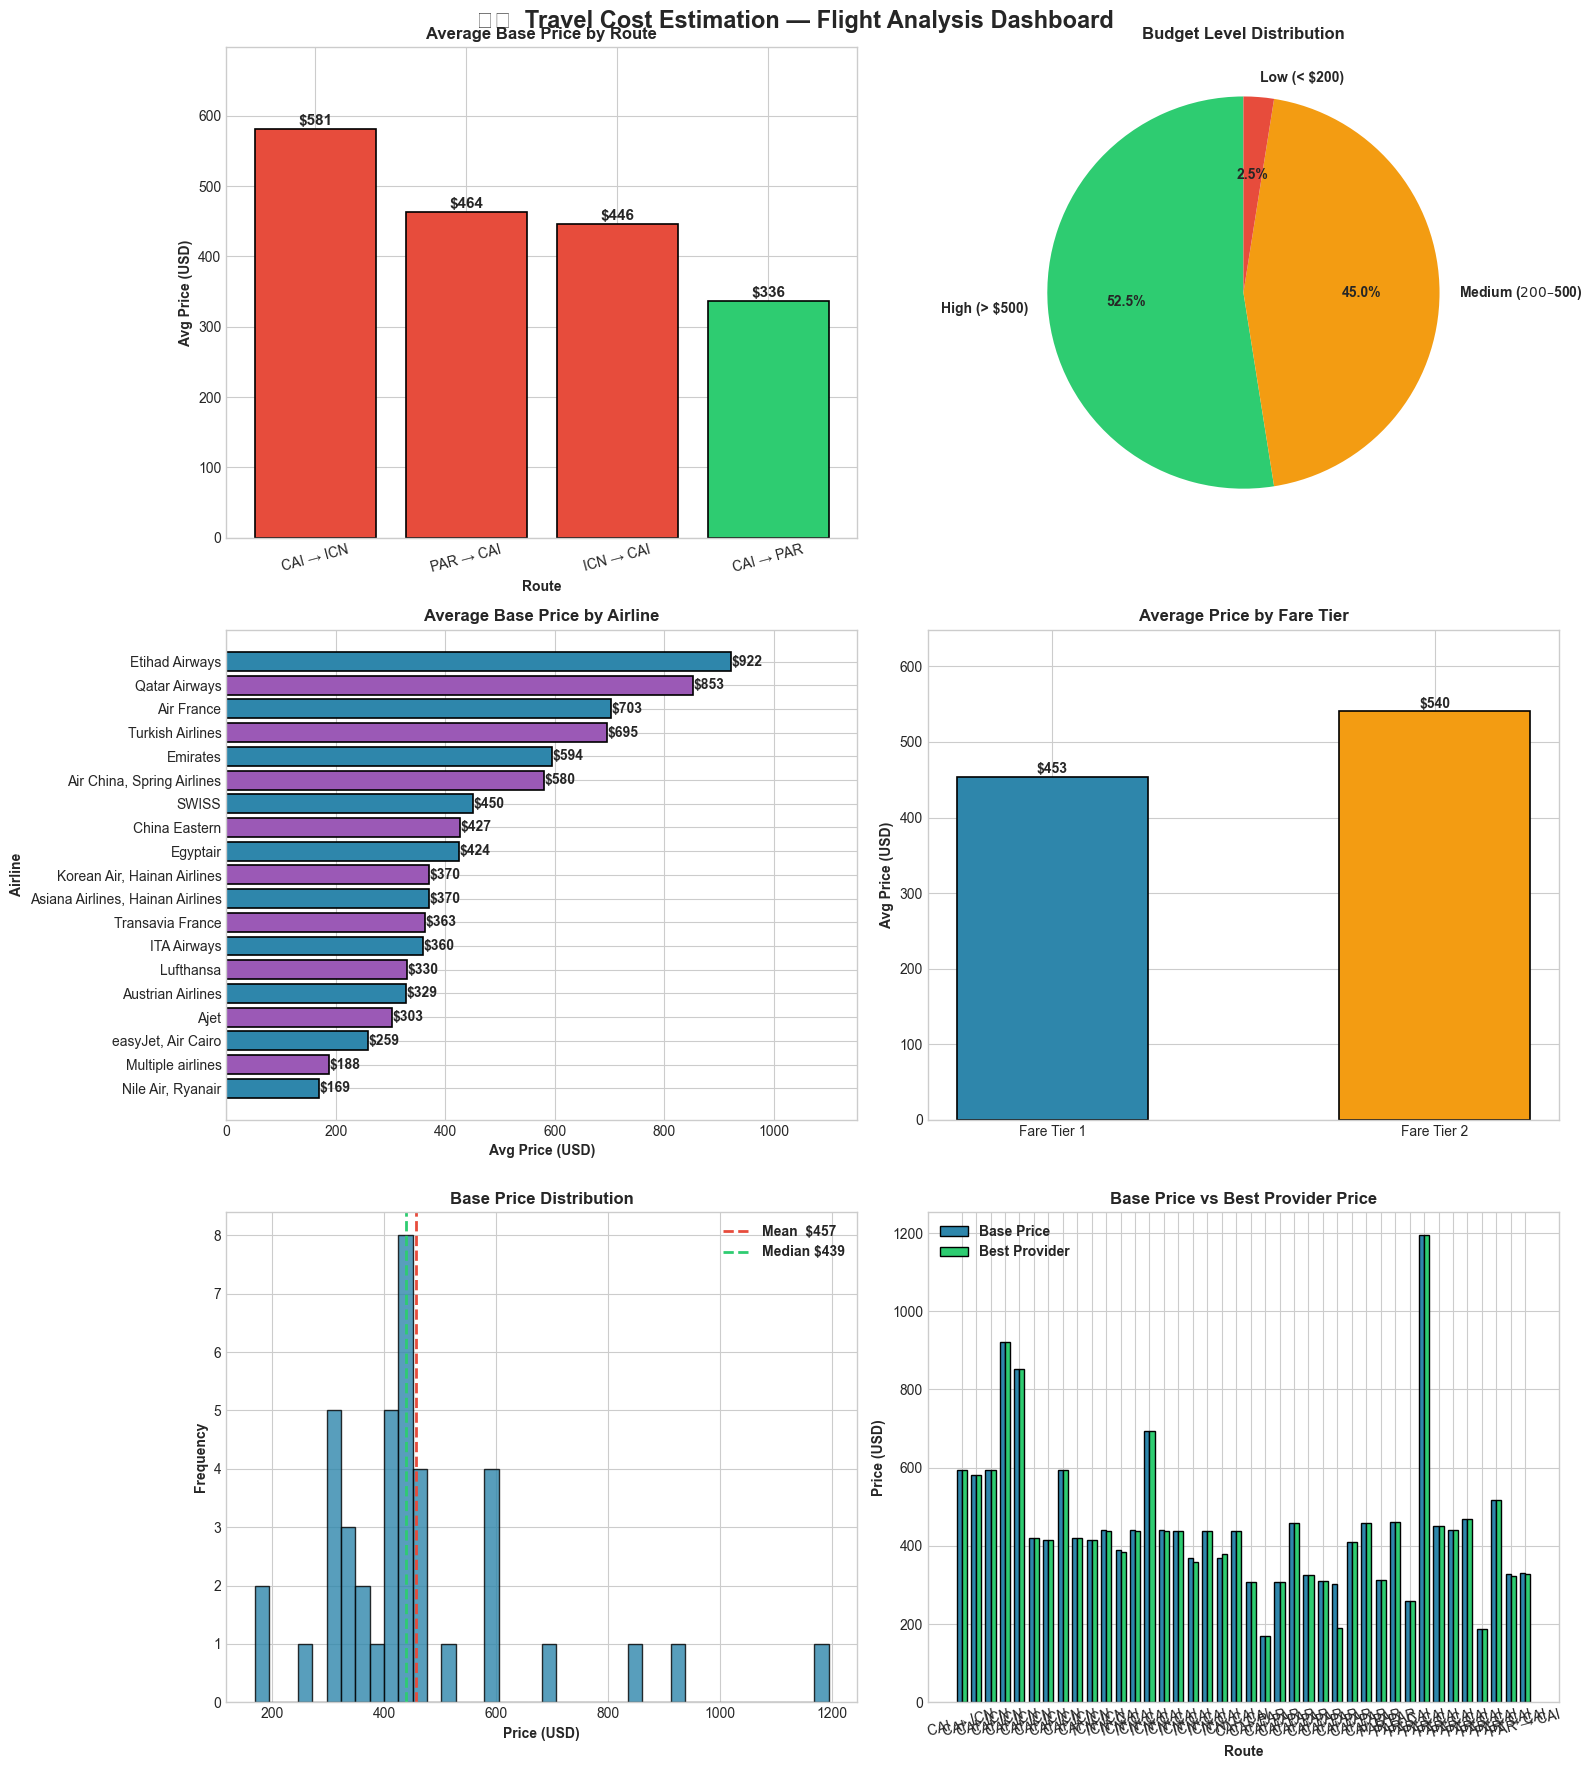

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('✈️  Travel Cost Estimation — Flight Analysis Dashboard',
             fontsize=17, fontweight='bold', y=0.98)

BLUE   = '#2E86AB'
GREEN  = '#2ecc71'
ORANGE = '#f39c12'
RED    = '#e74c3c'
PURPLE = '#9b59b6'

# ── Plot 1: Avg Base Price by Route ──────────────────────────────
ax1 = axes[0, 0]
route_prices = df_clean.groupby('route')['base_price'].mean().sort_values(ascending=False)
colors1 = [GREEN if p == route_prices.min() else RED for p in route_prices]
bars = ax1.bar(route_prices.index, route_prices.values, color=colors1, edgecolor='black', linewidth=1.2)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'${bar.get_height():.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.set_title('Average Base Price by Route', fontweight='bold', fontsize=12)
ax1.set_xlabel('Route', fontweight='bold')
ax1.set_ylabel('Avg Price (USD)', fontweight='bold')
ax1.tick_params(axis='x', rotation=15)
ax1.set_ylim(0, route_prices.max() * 1.2)

# ── Plot 2: Budget Level Pie Chart ────────────────────────────────
ax2 = axes[0, 1]
budget_data = df_clean['budget_level'].value_counts()
colors2 = [GREEN, ORANGE, RED][:len(budget_data)]
wedges, texts, autotexts = ax2.pie(
    budget_data.values, labels=budget_data.index,
    autopct='%1.1f%%', colors=colors2, startangle=90,
    textprops={'fontweight': 'bold', 'fontsize': 10}
)
ax2.set_title('Budget Level Distribution', fontweight='bold', fontsize=12)

# ── Plot 3: Base Price by Airline (bar) ───────────────────────────
ax3 = axes[1, 0]
airline_prices = df_clean.groupby('airline')['base_price'].mean().sort_values()
bars3 = ax3.barh(airline_prices.index, airline_prices.values,
                 color=[BLUE, PURPLE][:len(airline_prices)], edgecolor='black', linewidth=1.2)
for bar in bars3:
    ax3.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'${bar.get_width():.0f}', va='center', fontweight='bold')
ax3.set_title('Average Base Price by Airline', fontweight='bold', fontsize=12)
ax3.set_xlabel('Avg Price (USD)', fontweight='bold')
ax3.set_ylabel('Airline', fontweight='bold')
ax3.set_xlim(0, airline_prices.max() * 1.25)

# ── Plot 4: Fare Tier Comparison ─────────────────────────────────
ax4 = axes[1, 1]
fare_cols  = [c for c in ['fare_1_price', 'fare_2_price'] if c in df_clean.columns]
fare_means = df_clean[fare_cols].mean()
fare_labels = ['Fare Tier 1', 'Fare Tier 2'][:len(fare_means)]
bars4 = ax4.bar(fare_labels, fare_means.values,
                color=[BLUE, ORANGE], edgecolor='black', linewidth=1.2, width=0.5)
for bar in bars4:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'${bar.get_height():.0f}', ha='center', va='bottom', fontweight='bold')
ax4.set_title('Average Price by Fare Tier', fontweight='bold', fontsize=12)
ax4.set_ylabel('Avg Price (USD)', fontweight='bold')
ax4.set_ylim(0, fare_means.max() * 1.2)

# ── Plot 5: Base Price Distribution (Histogram) ───────────────────
ax5 = axes[2, 0]
ax5.hist(df_clean['base_price'], bins=max(5, len(df_clean)),
         color=BLUE, edgecolor='black', alpha=0.8)
ax5.axvline(df_clean['base_price'].mean(),   color=RED,   linestyle='--',
            linewidth=2, label=f'Mean  ${df_clean["base_price"].mean():.0f}')
ax5.axvline(df_clean['base_price'].median(), color=GREEN, linestyle='--',
            linewidth=2, label=f'Median ${df_clean["base_price"].median():.0f}')
ax5.set_title('Base Price Distribution', fontweight='bold', fontsize=12)
ax5.set_xlabel('Price (USD)', fontweight='bold')
ax5.set_ylabel('Frequency', fontweight='bold')
ax5.legend(prop={'weight': 'bold'})

# ── Plot 6: Provider Price Comparison (best offers) ───────────────
ax6 = axes[2, 1]
routes    = df_clean['route'].tolist()
base_ps   = df_clean['base_price'].tolist()
best_ps   = df_clean['best_provider_price'].tolist()
x         = range(len(routes))
width     = 0.35
ax6.bar([i - width/2 for i in x], base_ps, width, label='Base Price', color=BLUE,   edgecolor='black')
ax6.bar([i + width/2 for i in x], best_ps, width, label='Best Provider', color=GREEN, edgecolor='black')
ax6.set_title('Base Price vs Best Provider Price', fontweight='bold', fontsize=12)
ax6.set_xlabel('Route', fontweight='bold')
ax6.set_ylabel('Price (USD)', fontweight='bold')
ax6.set_xticks(list(x))
ax6.set_xticklabels(routes, rotation=15)
ax6.legend(prop={'weight': 'bold'})

plt.tight_layout()
print('✅  Dashboard saved: flight_analysis_dashboard.png')
plt.show()

---
## 💡 7. Key Insights & Summary

In [31]:
cheapest_route       = df_clean.groupby('route')['base_price'].mean().idxmin()
cheapest_route_price = df_clean.groupby('route')['base_price'].mean().min()
most_exp_route       = df_clean.groupby('route')['base_price'].mean().idxmax()
most_exp_route_price = df_clean.groupby('route')['base_price'].mean().max()

print('=' * 65)
print('              KEY INSIGHTS & SUMMARY')
print('=' * 65)

print(f"""
1. PRICING OVERVIEW
   • Average base price    : ${df_clean['base_price'].mean():.2f}
   • Average total cost    : ${df_clean['total_cost'].mean():.2f} (incl. 15% tax)
   • Price range           : ${df_clean['base_price'].min()} – ${df_clean['base_price'].max()}

2. ROUTE INSIGHTS
   • Cheapest route  : {cheapest_route} (avg ${cheapest_route_price:.2f})
   • Most expensive  : {most_exp_route} (avg ${most_exp_route_price:.2f})
   • Price gap       : ${most_exp_route_price - cheapest_route_price:.2f}

3. BUDGET DISTRIBUTION
   • Low  (< $200)       : {(df_clean['budget_level'] == 'Low (< $200)').sum()} flights
   • Medium ($200–$500)  : {(df_clean['budget_level'] == 'Medium ($200–$500)').sum()} flights
   • High (> $500)       : {(df_clean['budget_level'] == 'High (> $500)').sum()} flights

4. PROVIDER SAVINGS
   • Max saving vs listed price : ${df_clean['savings_vs_best'].max():.2f}
   • Avg saving                 : ${df_clean['savings_vs_best'].mean():.2f}
   • Best provider overall      : {df_clean.loc[df_clean['savings_vs_best'].idxmax(), 'best_provider_name']}

5. DATA QUALITY
   • Total records scraped : {len(df_raw)}
   • Clean records         : {len(df_clean)}
   • Outliers flagged      : {df_clean['is_outlier'].sum()} (retained for analysis)
   • Airlines covered      : {', '.join(df_clean['airline'].unique())}
   • Routes covered        : {', '.join(df_clean['route'].unique())}
""")

              KEY INSIGHTS & SUMMARY

1. PRICING OVERVIEW
   • Average base price    : $456.88
   • Average total cost    : $525.41 (incl. 15% tax)
   • Price range           : $169 – $1194

2. ROUTE INSIGHTS
   • Cheapest route  : CAI → PAR (avg $336.50)
   • Most expensive  : CAI → ICN (avg $581.10)
   • Price gap       : $244.60

3. BUDGET DISTRIBUTION
   • Low  (< $200)       : 1 flights
   • Medium ($200–$500)  : 18 flights
   • High (> $500)       : 21 flights

4. PROVIDER SAVINGS
   • Max saving vs listed price : $113.00
   • Avg saving                 : $3.45
   • Best provider overall      : Kiwi.com

5. DATA QUALITY
   • Total records scraped : 40
   • Clean records         : 40
   • Outliers flagged      : 4 (retained for analysis)
   • Airlines covered      : Emirates, Air China, Spring Airlines, Etihad Airways, Qatar Airways, China Eastern, Turkish Airlines, Asiana Airlines, Hainan Airlines, Korean Air, Hainan Airlines, Egyptair, Nile Air, Ryanair, Transavia France, Air Fr

In [32]:
# ── Save cleaned dataset ──────────────────────────────────────────
df_clean.to_excel('flights_dataset_clean.xlsx', index=False)
df_clean.to_csv('flights_dataset_clean.csv',   index=False)
print('✅  Cleaned dataset saved:')
print('     • flights_dataset_clean.xlsx')
print('     • flights_dataset_clean.csv')
print(f'\n   Final shape: {df_clean.shape}')
print(f'   Columns: {list(df_clean.columns)}')

✅  Cleaned dataset saved:
     • flights_dataset_clean.xlsx
     • flights_dataset_clean.csv

   Final shape: (40, 25)
   Columns: ['origin', 'destination', 'route', 'date', 'day_of_week', 'month', 'airline', 'duration', 'duration_min', 'from_time', 'to_time', 'stops_raw', 'num_stops', 'cabin_class', 'base_price', 'tax', 'total_cost', 'fare_1_price', 'fare_2_price', 'best_provider_name', 'best_provider_price', 'savings_vs_best', 'budget_level', 'affordability_score', 'is_outlier']
